# CLINC150 — calibrated abstention with the hybrid retrieval-fusion classifier

This notebook is an end-to-end, **fully offline** walkthrough of the
[`text_classifier`](../../README.md) package on
[CLINC150](https://github.com/clinc/oos-eval): 150 fine-grained user intents
across 10 domains, plus an explicit **out-of-scope (OOS)** set of queries that
belong to none of them.

That OOS set is exactly what makes CLINC150 a good showcase for this package.
The model learns the in-scope intents, and the OOS queries are precisely what a
*calibrated, abstaining* classifier should decline — routing them to a human
instead of guessing.

### What you'll do here

1. **Prepare** the dataset into the package's two-CSV input shape.
2. **Train** a classifier completely offline using the torch-free TF-IDF encoder.
3. **Evaluate** it on in-scope test data — coverage, accuracy-on-accepted, and
   calibration (Brier / ECE).
4. **Watch it abstain** on out-of-scope queries.
5. **Tune the operating point** and see the core risk–coverage trade-off that
   every human-in-the-loop system lives on.

Everything runs without a network connection or a GPU. The only step that
touches the network is the one-time dataset download (~2.5 MB).

> **TF-IDF is the floor, not the ceiling.** This demo uses a corpus-fitted
> TF-IDF encoder so it runs anywhere with no model download. A real
> sentence-transformer bi-encoder separates in-scope from out-of-scope queries
> noticeably better at the same coverage — swap `kind="tfidf"` for
> `kind="sentence-transformers"` once you have network access.

## 1. Setup

Install the package from the repository root. The TF-IDF path needs only the
core scientific Python stack (no PyTorch); `matplotlib` is used here for the
plots.

```bash
pip install .            # core package
pip install matplotlib   # for the charts in this notebook
```

The cell below imports what we need and locates the repository root, so the
notebook works whether you launch Jupyter from the repo root or from this
`examples/clinc150/` directory.

In [1]:
import json
import logging
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import text_classifier
from text_classifier import (
    PipelineConfig, LabelSpace, ClassDefinition, LabeledItem,
    TrainingPipeline, InferencePipeline,
)
from text_classifier.application.evaluation import evaluate_decisions

# Keep the pipeline's own INFO logs quiet; we present results ourselves below.
logging.getLogger("text_classifier").setLevel(logging.WARNING)

# A clean, consistent look for every chart in the notebook.
plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("text_classifier version:", text_classifier.__version__)
print("Python:", sys.version.split()[0])

text_classifier version: 0.1.0
Python: 3.11.15


In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    # Walk upward from `start` (default: cwd) until we find the package root,
    # so the notebook runs from the repo root or from this examples/ directory.
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "text_classifier").is_dir():
            return candidate
    raise RuntimeError("Could not locate the repository root from %s" % here)

REPO_ROOT = find_repo_root()
EXAMPLE_DIR = REPO_ROOT / "examples" / "clinc150"
BUILD = EXAMPLE_DIR / "build"          # all generated artifacts land here (git-ignored)
MODEL_DIR = BUILD / "model"

print("repository root :", REPO_ROOT)
print("example dir     :", EXAMPLE_DIR)
print("build dir       :", BUILD)

repository root : /home/user/Hybrid-retrieval-fusion-text-classifier
example dir     : /home/user/Hybrid-retrieval-fusion-text-classifier/examples/clinc150
build dir       : /home/user/Hybrid-retrieval-fusion-text-classifier/examples/clinc150/build


## 2. Prepare the data

`prepare.py` downloads the canonical CLINC150 file once and writes the
package's input shape:

| file | columns | role |
|------|---------|------|
| `classes.csv`     | `key,description` | the in-scope intents the model can predict |
| `items_train.csv` | `text,label`      | in-scope training queries |
| `items_test.csv`  | `text,label`      | in-scope test queries → **evaluate** |
| `items_oos.csv`   | `text,label`      | out-of-scope queries → **should abstain** |

We subsample to **40 intents × 60 queries** for a fast local run. Drop
`--max-classes` / `--per-class` for the full 150-intent dataset.

> The class **descriptions** are humanized from the intent key
> (`bill_balance` → *"A user request about bill balance."*). They are
> deliberately simple — hand-writing richer descriptions is the first thing to
> improve for a production-grade demo, since they feed the
> description-similarity signal directly.

In [3]:
cmd = [
    sys.executable, str(EXAMPLE_DIR / "prepare.py"),
    "--max-classes", "40",
    "--per-class", "60",
]
print("$", " ".join(cmd), "\n")
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise SystemExit("prepare.py failed — see the error above.")

$ /usr/bin/python3 /home/user/Hybrid-retrieval-fusion-text-classifier/examples/clinc150/prepare.py --max-classes 40 --per-class 60 

40 in-scope intents
wrote     40 rows -> /home/user/Hybrid-retrieval-fusion-text-classifier/examples/clinc150/build/classes.csv
wrote   2400 rows -> /home/user/Hybrid-retrieval-fusion-text-classifier/examples/clinc150/build/items_train.csv
wrote   1200 rows -> /home/user/Hybrid-retrieval-fusion-text-classifier/examples/clinc150/build/items_test.csv
wrote   1000 rows -> /home/user/Hybrid-retrieval-fusion-text-classifier/examples/clinc150/build/items_oos.csv

Next:
  text-classifier-train --items /home/user/Hybrid-retrieval-fusion-text-classifier/examples/clinc150/build/items_train.csv --classes /home/user/Hybrid-retrieval-fusion-text-classifier/examples/clinc150/build/classes.csv --out /home/user/Hybrid-retrieval-fusion-text-classifier/examples/clinc150/build/model --encoder-kind tfidf
  text-classifier-eval  --model /home/user/Hybrid-retrieval-fusion-text

Let's look at what we just built. CLINC150 is class-balanced in-scope by
construction, so this demo showcases **abstention** rather than class imbalance
(for an imbalanced showcase, an arXiv-abstract → primary-category demo is a
better fit).

In [4]:
classes = pd.read_csv(BUILD / "classes.csv")
train   = pd.read_csv(BUILD / "items_train.csv")
test    = pd.read_csv(BUILD / "items_test.csv")
oos     = pd.read_csv(BUILD / "items_oos.csv")

summary = pd.DataFrame(
    {
        "rows":    [len(train), len(test), len(oos)],
        "classes": [train.label.nunique(), test.label.nunique(), 1],
    },
    index=["items_train (in-scope)", "items_test (in-scope)", "items_oos (out-of-scope)"],
)
print("in-scope intents:", len(classes))
summary

in-scope intents: 40


,rows,classes
items_train (in-scope),2400,40
items_test (in-scope),1200,40
items_oos (out-of-scope),1000,1


In [5]:
print("Example class definitions:")
display(classes.head(5))

print("Example in-scope training queries:")
display(train.head(5))

print("Example out-of-scope queries (these should be abstained on):")
display(oos.sample(5, random_state=0).reset_index(drop=True))

Example class definitions:


,key,description
0,accept_reservations,A user request about accept reservations.
1,account_blocked,A user request about account blocked.
2,alarm,A user request about alarm.
3,application_status,A user request about application status.
4,apr,A user request about apr.


Example in-scope training queries:


,text,label
0,what is the meaning of realism,definition
1,what is regard mean,definition
2,what is the meaning of interorganizational,definition
3,what is it is all relative mean,definition
4,what is intercontinental mean,definition


Example out-of-scope queries (these should be abstained on):


,text,label
0,can you detect where i placed my wallet,oos
1,how do you relieve a hangover,oos
2,what year did my grandparents get married,oos
3,did a man really die trying to be loved by a h...,oos
4,tell me where i can get the cheapest tennis ba...,oos


## 3. How the model works (in one paragraph)

For every item, five retrieval signals are scored against the candidate
classes — dense and BM25 similarity to each class **description**, dense
similarity to each class **prototype**, and dense / BM25 **kNN** over the
training examples. A single pointwise model (XGBoost) **fuses** those ~28
features into a calibrated `P(this candidate is the true class)`. The
confidence is **isotonic-calibrated**, and an **abstention threshold** is tuned
to hold a target accuracy on the items the system accepts.

The knob that matters for this demo is **`target_precision`**: the minimum
accuracy required on accepted items. The tuner picks the lowest threshold that
still meets it — raising the bar makes the system more conservative, which
rejects more out-of-scope queries at the cost of in-scope coverage.

See the [top-level README](../../README.md) for the full architecture and the
leakage-control story (out-of-fold features, held-out calibration).

## 4. Train — offline, with the TF-IDF encoder

We drive the library directly rather than the CLI so we can inspect the
returned objects. The equivalent one-liner is shown at the end of the notebook.

`TrainingPipeline.run` does the whole job: out-of-fold feature generation,
fusion-model training, isotonic calibration, threshold tuning, and a held-out
evaluation — then writes a portable model directory plus `evaluation.json` and
`model_card.md`.

In [6]:
# Build the label space and the training items from the CSVs.
label_space = LabelSpace([
    ClassDefinition(key, desc) for key, desc in zip(classes.key, classes.description)
])
items = [LabeledItem(text, label) for text, label in zip(train.text, train.label)]

# Configure: torch-free TF-IDF encoder, and a strict 0.99 target accuracy on
# accepted items so abstention is clearly in play.
config = PipelineConfig()
config.encoder.kind = "tfidf"
config.training.target_precision = 0.99

print(f"Training on {len(items)} items across {label_space.size} classes "
      f"(target_precision={config.training.target_precision}) ...")
artifacts, report = TrainingPipeline(config).run(items, label_space, output_dir=str(MODEL_DIR))
print("done.")

Training on 2400 items across 40 classes (target_precision=0.99) ...


done.


The returned `CoverageReport` is computed on a **held-out test fold the fusion
model never saw** — the leakage-free headline:

- **candidate recall** — fraction of items whose true class made the candidate
  set. This is the *ceiling* on accuracy: a class that never becomes a candidate
  can never be predicted.
- **coverage** — fraction of items the system accepted (did not abstain on).
- **accuracy on accepted** — accuracy over those accepted items; this is what
  `target_precision` constrains.

In [7]:
report_table = pd.Series({
    "candidate recall (accuracy ceiling)": report.candidate_recall,
    "coverage (accepted fraction)":        report.coverage,
    "accuracy on accepted":                report.accuracy_on_accepted,
    "accuracy if never abstaining":        report.accuracy_if_no_abstain,
    "items evaluated":                     report.n_items,
}).to_frame("value")
report_table

,value
candidate recall (accuracy ceiling),1.000000
coverage (accepted fraction),0.754167
accuracy on accepted,0.991713
accuracy if never abstaining,0.956250
items evaluated,480.000000


### The trained model directory is self-describing

Every trained directory carries its own evidence so it can be audited after the
fact. `model_card.md` is the human-readable summary; `evaluation.json` holds the
full per-class breakdown, reliability table, and risk-coverage curve.

In [8]:
print("Files in the model directory:")
for path in sorted(MODEL_DIR.iterdir()):
    print("  ", path.name)

print("\n--- model_card.md ---\n")
print((MODEL_DIR / "model_card.md").read_text())

Files in the model directory:
   calibrator.pkl
   dense.npz
   encoder
   evaluation.json
   fusion.json
   lexical.pkl
   meta.json
   model_card.md

--- model_card.md ---

# Model card

- **Package version:** 0.1.0
- **Generated:** 2026-06-30T06:27:26+00:00
- **Classes:** 40
- **Training items:** 2400
- **Encoder / fusion / calibrator:** tfidf / xgboost / isotonic
- **Target accuracy on accepted:** 0.99

## Headline metrics (held-out)

- **Coverage:** 75.4% (362 accepted of 480)
- **Accuracy on accepted:** 99.2%
- **Accuracy if never abstaining:** 95.6%
- **Candidate recall (accuracy ceiling):** 100.0%
- **Expected calibration error:** 0.0241
- **Brier score:** 0.0378

## Abstention thresholds

- **Global threshold:** 0.9697
- **Per-class thresholds:** 0 class(es) had enough calibration support for their own threshold; the rest fall back to the global one.

See `evaluation.json` for the per-class breakdown, reliability table, and risk-coverage curve.



## 5. Evaluate on the in-scope test set

Now we score the never-before-seen in-scope test queries and assemble the full
evaluation. Inference is leakage-free by construction — a genuinely new item has
no self-match in the index.

In [9]:
pipeline = InferencePipeline.from_directory(str(MODEL_DIR))
keys = pipeline.label_space.keys
key_to_idx = {k: i for i, k in enumerate(keys)}

test_preds = pipeline.predict(list(test.text))

confidence = np.array([p.confidence for p in test_preds])
accepted   = np.array([not p.abstained for p in test_preds])
correct    = np.array([p.top_key == lbl for p, lbl in zip(test_preds, test.label)])

evaluation = evaluate_decisions(
    confidence=confidence,
    correct=correct,
    accepted=accepted,
    pred_idx=np.array([key_to_idx.get(p.top_key, -1) for p in test_preds]),
    true_idx=np.array([key_to_idx[lbl] for lbl in test.label]),
    keys=keys,
)

overall = evaluation["overall"]
calib   = evaluation["calibration"]
pd.Series({
    "items evaluated":        overall["n_items"],
    "coverage":               overall["coverage"],
    "accuracy on accepted":   overall["accuracy_on_accepted"],
    "accuracy if no abstain": overall["accuracy_if_no_abstain"],
    "Brier score":            calib["brier_score"],
    "expected calib. error":  calib["expected_calibration_error"],
}).to_frame("value")

,value
items evaluated,1200.000000
coverage,0.682500
accuracy on accepted,0.976801
accuracy if no abstain,0.910833
Brier score,0.065819
expected calib. error,0.034888


### Calibration: is the confidence trustworthy?

The abstention threshold is only meaningful if the confidence it acts on is
*calibrated* — i.e. items the model is "90% sure" about really are right ~90% of
the time. The reliability diagram plots, per confidence bin, the model's mean
confidence against the observed accuracy. A perfectly calibrated model sits on
the diagonal.

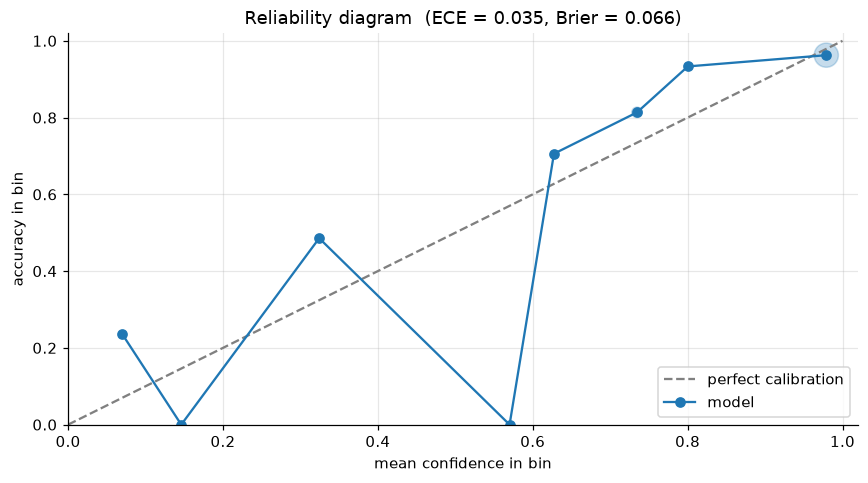

In [10]:
rel = pd.DataFrame(calib["reliability_table"])

fig, ax = plt.subplots()
ax.plot([0, 1], [0, 1], "--", color="grey", label="perfect calibration")
ax.plot(rel["mean_confidence"], rel["accuracy"], "o-", color="#1f77b4", label="model")
# Size each marker by how many items fell in that bin.
ax.scatter(rel["mean_confidence"], rel["accuracy"],
           s=rel["count"] / rel["count"].max() * 250, color="#1f77b4", alpha=0.25)
ax.set_xlabel("mean confidence in bin")
ax.set_ylabel("accuracy in bin")
ax.set_title(f"Reliability diagram  (ECE = {calib['expected_calibration_error']:.3f}, "
             f"Brier = {calib['brier_score']:.3f})")
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

### The risk–coverage curve

This is the central trade-off for a human-in-the-loop system: as you accept
fewer items (lower coverage), the ones you *do* accept are more accurate (lower
risk). The curve is the model-independent ceiling on what any single global
threshold can achieve — it's the shape a reviewer reads to choose an operating
point.

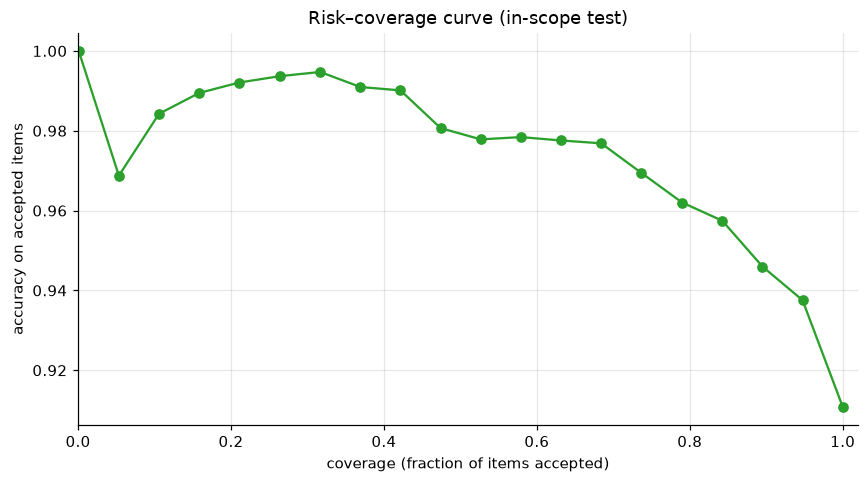

In [11]:
rc = pd.DataFrame(evaluation["risk_coverage_curve"])

fig, ax = plt.subplots()
ax.plot(rc["coverage"], rc["accuracy"], "o-", color="#2ca02c")
ax.set_xlabel("coverage (fraction of items accepted)")
ax.set_ylabel("accuracy on accepted items")
ax.set_title("Risk–coverage curve (in-scope test)")
ax.set_xlim(0, 1.02)
plt.tight_layout(); plt.show()

## 6. The headline: abstaining on out-of-scope queries

For OOS queries the *desired* outcome is to **abstain** — they belong to none of
the in-scope intents, so accepting one means confidently emitting a wrong label.
We run the same pipeline on `items_oos.csv` and measure the abstention rate.

In [12]:
oos_preds = pipeline.predict(list(oos.text))
oos_confidence = np.array([p.confidence for p in oos_preds])
oos_abstained  = np.array([p.abstained for p in oos_preds])

n = len(oos_preds)
n_abstained = int(oos_abstained.sum())
print(f"out-of-scope queries : {n}")
print(f"correctly abstained  : {n_abstained}  ({100 * n_abstained / n:.1f}%)")
print(f"wrongly accepted     : {n - n_abstained}  ({100 * (n - n_abstained) / n:.1f}%)")

# Show a few OOS queries the model *wrongly* accepted (thought were in-scope).
wrong = [
    {"confidence": round(p.confidence, 3), "predicted_key": p.top_key, "text": t}
    for p, t in zip(oos_preds, oos.text) if not p.abstained
]
if wrong:
    print("\nExamples wrongly accepted (model thought these were in-scope):")
    display(pd.DataFrame(wrong).head(10))

out-of-scope queries : 1000
correctly abstained  : 945  (94.5%)
wrongly accepted     : 55  (5.5%)

Examples wrongly accepted (model thought these were in-scope):


,confidence,predicted_key,text
0,0.986,definition,what does the plus sign mean on my dashboard
1,0.970,balance,what is my checking account number
2,0.970,credit_score,can you tell me the score of the heat game
3,0.970,cancel,should i do a complete stop at red lights
4,1.000,date,can you tell me today's headlines pleasei
5,0.970,cook_time,what time do i need to arrive to make it on time
6,0.970,bill_balance,how much data does my phone have left this month
7,0.970,account_blocked,how hard is it to close a bank account at well...
8,0.970,alarm,create a contact labeled mom
9,0.970,direct_deposit,can i use direct deposit for my tax refund


### Why it works: confidence separates in-scope from out-of-scope

Abstention works because the calibrated confidence on OOS queries is pushed low,
while in-scope queries keep high confidence. The two distributions are visibly
separated — the abstention threshold simply cuts between them.

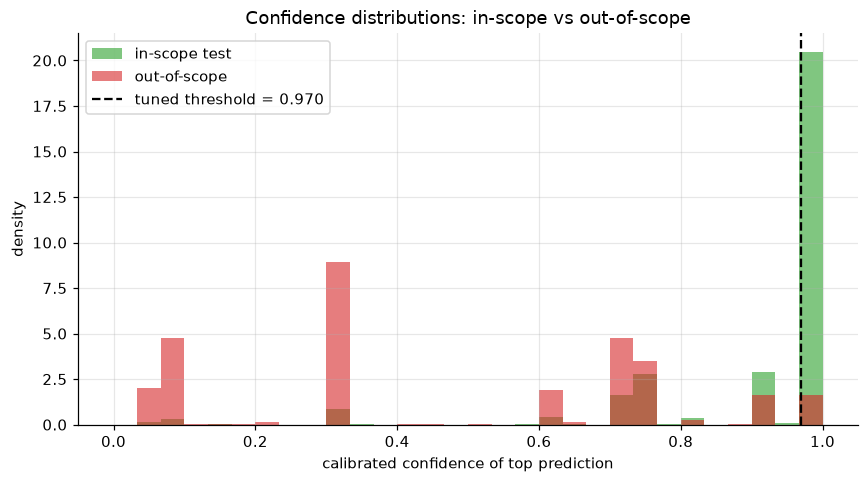

In [13]:
global_threshold = artifacts.abstention.global_threshold

fig, ax = plt.subplots()
bins = np.linspace(0, 1, 31)
ax.hist(confidence, bins=bins, alpha=0.6, density=True,
        label="in-scope test", color="#2ca02c")
ax.hist(oos_confidence, bins=bins, alpha=0.6, density=True,
        label="out-of-scope", color="#d62728")
ax.axvline(global_threshold, color="black", linestyle="--",
           label=f"tuned threshold = {global_threshold:.3f}")
ax.set_xlabel("calibrated confidence of top prediction")
ax.set_ylabel("density")
ax.set_title("Confidence distributions: in-scope vs out-of-scope")
ax.legend()
plt.tight_layout(); plt.show()

## 7. The operating point is a real choice

Everything above used one tuned threshold. But the threshold is a **knob**, and
where you set it is a business decision driven by *your* cost of a wrong answer
versus a human review. Sweeping it traces the whole trade-off in one chart:

- **in-scope coverage** — how much traffic you auto-handle (falls as you raise
  the bar),
- **in-scope accuracy on accepted** — quality of what you auto-handle (rises),
- **OOS rejected** — how much out-of-scope traffic you correctly decline (rises).

Because confidence is calibrated, we can sweep the threshold directly on the
confidences we already computed — no retraining needed.

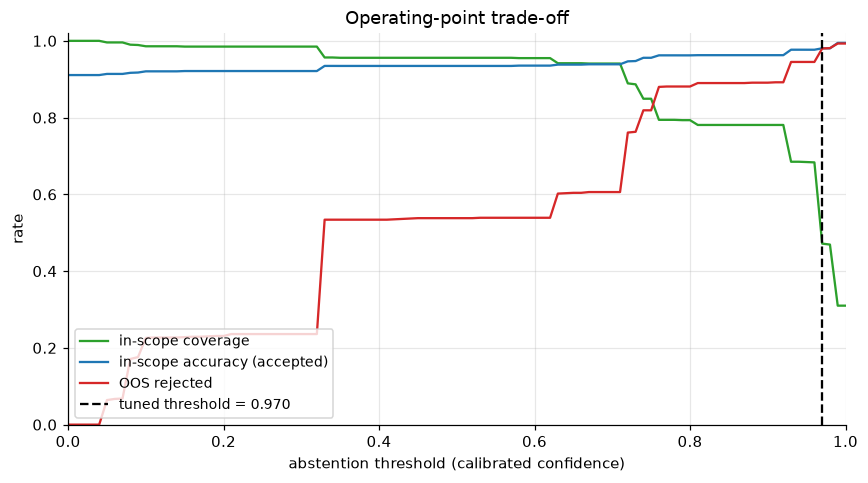

In [14]:
thresholds = np.linspace(0.0, 1.0, 101)

def coverage_at(t):
    return float((confidence >= t).mean())

def accuracy_on_accepted_at(t):
    mask = confidence >= t
    return float(correct[mask].mean()) if mask.any() else np.nan

def oos_rejected_at(t):
    return float((oos_confidence < t).mean())

sweep = pd.DataFrame({
    "threshold":             thresholds,
    "in_scope_coverage":     [coverage_at(t) for t in thresholds],
    "in_scope_accuracy":     [accuracy_on_accepted_at(t) for t in thresholds],
    "oos_rejected":          [oos_rejected_at(t) for t in thresholds],
})

fig, ax = plt.subplots()
ax.plot(sweep.threshold, sweep.in_scope_coverage, label="in-scope coverage", color="#2ca02c")
ax.plot(sweep.threshold, sweep.in_scope_accuracy, label="in-scope accuracy (accepted)", color="#1f77b4")
ax.plot(sweep.threshold, sweep.oos_rejected, label="OOS rejected", color="#d62728")
ax.axvline(global_threshold, color="black", linestyle="--",
           label=f"tuned threshold = {global_threshold:.3f}")
ax.set_xlabel("abstention threshold (calibrated confidence)")
ax.set_ylabel("rate")
ax.set_title("Operating-point trade-off")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout(); plt.show()

Reading a few operating points off the sweep makes the trade-off concrete:

In [15]:
def summarize(t):
    return {
        "threshold":          round(t, 3),
        "in-scope coverage":  f"{100 * coverage_at(t):.1f}%",
        "in-scope accuracy":  f"{100 * accuracy_on_accepted_at(t):.1f}%",
        "OOS rejected":       f"{100 * oos_rejected_at(t):.1f}%",
    }

points = [0.50, 0.90, global_threshold, 0.99]
pd.DataFrame([summarize(t) for t in points])

,threshold,in-scope coverage,in-scope accuracy,OOS rejected
0,0.50,95.6%,93.5%,53.8%
1,0.90,78.1%,96.3%,89.1%
2,0.97,68.2%,97.7%,94.5%
3,0.99,31.0%,99.5%,99.3%


**Takeaways**

- **The operating point is a real choice.** A low threshold accepts almost all
  in-scope traffic but lets out-of-scope queries leak through; a high one rejects
  most OOS while auto-handling less in-scope traffic. Pick the point from your
  own cost of a wrong answer vs. a human review.
- **Calibration is what makes the threshold meaningful.** The reliability table
  and ECE above are not decoration — the threshold is only as trustworthy as the
  calibration behind it.
- **A real bi-encoder separates OOS better** at a given coverage than TF-IDF.
  This offline run is the floor, not the ceiling.

## 8. Classifying new text in code

In production you load a saved model directory once and call `predict` on a
batch of strings. Each `Prediction` carries the decision plus the best candidate
(`top_key`) so a human queue can still see the model's guess even when it
abstains.

In [16]:
demo_queries = [
    "what is the balance on my checking account",   # in-scope-ish
    "remind me to call mom at 6pm",                  # in-scope-ish
    "cancel my dinner reservation for tonight",      # in-scope-ish
    "i want to learn how to play the violin",        # clearly out-of-scope
    "write me a poem about the ocean",               # clearly out-of-scope
]

for query, pred in zip(demo_queries, pipeline.predict(demo_queries)):
    verdict = pred.predicted_key if not pred.abstained else "ABSTAIN → route to human"
    print(f"[conf={pred.confidence:0.3f}] {verdict:<28} (top guess: {pred.top_key:<18}) | {query}")

[conf=0.986] balance                      (top guess: balance           ) | what is the balance on my checking account
[conf=0.719] ABSTAIN → route to human     (top guess: change_user_name  ) | remind me to call mom at 6pm
[conf=1.000] cancel_reservation           (top guess: cancel_reservation) | cancel my dinner reservation for tonight
[conf=0.041] ABSTAIN → route to human     (top guess: alarm             ) | i want to learn how to play the violin
[conf=0.324] ABSTAIN → route to human     (top guess: do_you_have_pets  ) | write me a poem about the ocean


## 9. The same workflow from the command line

Everything above is also available as console scripts (installed with the
package). This is the path the example's `README.md` documents:

```bash
B=examples/clinc150/build

# 1. Build the CSVs (downloads CLINC150 once).
python examples/clinc150/prepare.py --out $B --max-classes 40 --per-class 60

# 2. Train offline with the TF-IDF encoder, targeting 0.99 accuracy on accepted.
text-classifier-train --items $B/items_train.csv --classes $B/classes.csv \
    --out $B/model --encoder-kind tfidf --target-precision 0.99

# 3. Evaluate on in-scope test — coverage, accuracy, calibration, per-class.
text-classifier-eval --model $B/model --input $B/items_test.csv \
    --output $B/in_scope_report.json

# 4. Show abstention on out-of-scope queries.
text-classifier-infer --model $B/model --input $B/items_oos.csv \
    --output $B/oos_preds.csv
python examples/clinc150/check_oos.py $B/oos_preds.csv
```

## 10. Notes & next steps

- **Richer class descriptions** are the first thing to improve for a
  production-grade demo: they feed the description-similarity signal and the
  (optional) encoder fine-tuning directly.
- **Swap the encoder** — set `config.encoder.kind = "sentence-transformers"`
  (the default) for a real bi-encoder when you have network access; it separates
  in-scope from out-of-scope queries better at a given coverage.
- **Scale up** — drop `--max-classes` / `--per-class` in step 2 to train on the
  full 150-intent dataset.
- `build/` and the downloaded `data_full.json` are git-ignored; they are
  regenerated by `prepare.py`.